In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC, LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
import joblib
import warnings
warnings.filterwarnings("ignore")
RANDOM_STATE = 42

In [2]:
fake_path = "fake.csv"
true_path = "true.csv"

df_fake = pd.read_csv(fake_path)
df_true = pd.read_csv(true_path)

In [3]:
print("Fake shape:", df_fake.shape)
print("True shape:", df_true.shape)

def prepare_df(df, label):
    # Ensure title and text exist; create if necessary
    title_col = "title" if "title" in df.columns else None
    text_col = "text" if "text" in df.columns else None
    # Fallback column names sometimes are 'headline' or 'content'
    if title_col is None and "headline" in df.columns:
        title_col = "headline"
    if text_col is None and "content" in df.columns:
        text_col = "content"
    # Compose a single text field
    parts = []
    if title_col:
        parts.append(df[title_col].astype(str))
    if text_col:
        parts.append(df[text_col].astype(str))
    if parts:
        combined = parts[0]
        for p in parts[1:]:
            combined = combined + ". " + p
    else:
        # If no title/text columns found, take the first textual column
        text_cols = df.select_dtypes(include='object').columns.tolist()
        if len(text_cols) > 0:
            combined = df[text_cols[0]].astype(str)
        else:
            combined = pd.Series([""]*len(df))
    out = pd.DataFrame({
        "text": combined,
        "label": label
    })
    return out

df_f = prepare_df(df_fake, label=1)   # 1 -> fake
df_t = prepare_df(df_true, label=0)   # 0 -> real

df = pd.concat([df_f, df_t], ignore_index=True).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
print("Combined shape:", df.shape)
display(df.head(3))

Fake shape: (23481, 4)
True shape: (21417, 4)
Combined shape: (44898, 2)


,text,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,1
1,Trump drops Steve Bannon from National Securit...,0
2,Puerto Rico expects U.S. to lift Jones Act shi...,0



Label distribution:
label
1    23481
0    21417
Name: count, dtype: int64

Text length stats:
count    44898.000000
mean      2551.221413
std       2172.578772
min         32.000000
25%       1319.000000
50%       2271.000000
75%       3190.000000
max      51894.000000
Name: text_len, dtype: float64


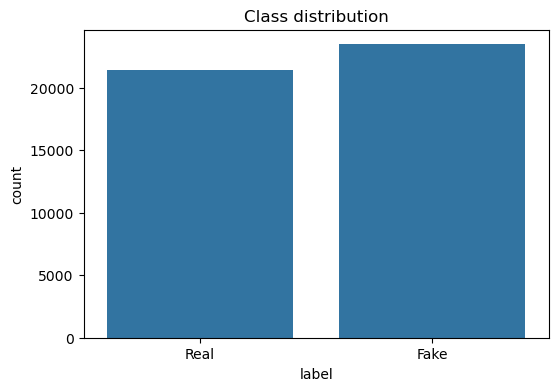

In [4]:
print("\nLabel distribution:")
print(df['label'].value_counts())

# Show text length stats (optional)
df['text_len'] = df['text'].str.len()
print("\nText length stats:")
print(df['text_len'].describe())

# Plot label distribution
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.xticks([0,1], ['Real', 'Fake'])
plt.title("Class distribution")
plt.show()

In [5]:
X = df['text'].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train size:", len(X_train), "Test size:", len(X_test))
print("Train label counts:", np.bincount(y_train))
print("Test label counts:", np.bincount(y_test))

Train size: 35918 Test size: 8980
Train label counts: [17133 18785]
Test label counts: [4284 4696]



Baseline metrics (default hyperparams):
Accuracy: 0.9963251670378619
Precision: 0.9972275538494348
Recall: 0.995741056218058
F1: 0.9964837506659563

Classification report:
              precision    recall  f1-score   support

        Real       1.00      1.00      1.00      4284
        Fake       1.00      1.00      1.00      4696

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



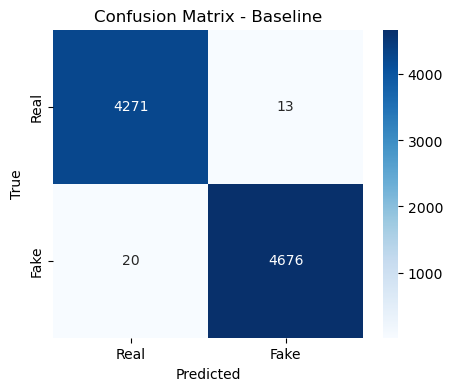

In [6]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words='english',
        max_df=0.9,
        min_df=5,           # ignore very rare words
        ngram_range=(1,2),  # unigrams + bigrams
        max_features=None   # you can set e.g. 50000 for speed/memory control
    )),
    ("clf", LinearSVC(random_state=RANDOM_STATE, max_iter=5000))
])

# Quick baseline: fit default pipeline and evaluate
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print("\nBaseline metrics (default hyperparams):")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=['Real','Fake']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real','Fake'], yticklabels=['Real','Fake'])
plt.ylabel('True')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Baseline')
plt.show()

Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best params: {'clf__C': 1, 'tfidf__min_df': 10, 'tfidf__ngram_range': (1, 2)}
Best CV score (F1): 0.9954988758072638

Best estimator metrics on test set:
Accuracy: 0.9968819599109131
Precision: 0.9974424552429667
Recall: 0.9965928449744463
F1: 0.9970174691095015

Classification report (best):
              precision    recall  f1-score   support

        Real       1.00      1.00      1.00      4284
        Fake       1.00      1.00      1.00      4696

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



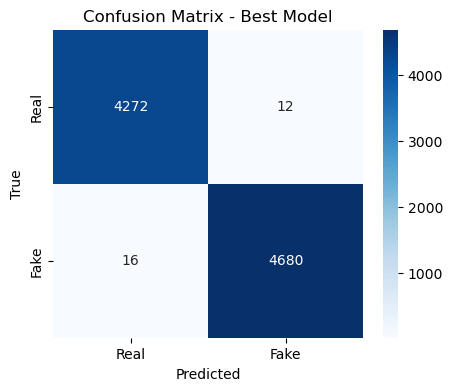

In [7]:
param_grid = {
    "tfidf__min_df": [3, 5, 10],
    "tfidf__ngram_range": [(1,1), (1,2)],
    "clf__C": [0.1, 1, 3]
}

# Use StratifiedKFold and GridSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='f1',    # optimize for F1 (balance precision + recall)
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)
print("\nBest params:", grid.best_params_)
print("Best CV score (F1):", grid.best_score_)

# Evaluate best estimator on test set
best = grid.best_estimator_
y_pred_best = best.predict(X_test)

print("\nBest estimator metrics on test set:")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))
print("F1:", f1_score(y_test, y_pred_best))
print("\nClassification report (best):")
print(classification_report(y_test, y_pred_best, target_names=['Real','Fake']))

# Confusion matrix for best
cm2 = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5,4))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', xticklabels=['Real','Fake'], yticklabels=['Real','Fake'])
plt.ylabel('True')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Best Model')
plt.show()

ROC AUC (using decision_function): 0.9998744387022271


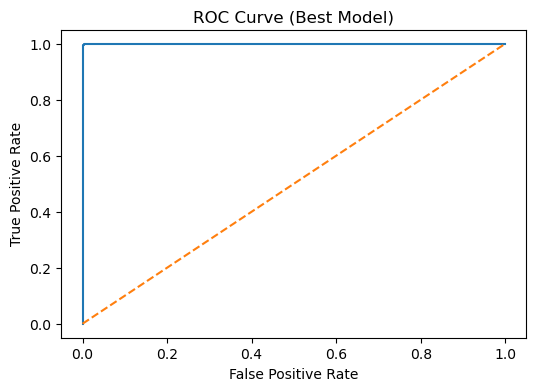

In [8]:
if hasattr(best.named_steps['clf'], "decision_function"):
    y_scores = best.decision_function(X_test)
    fpr, tpr, thresholds = roc_curve(y_test, y_scores)
    auc_val = roc_auc_score(y_test, y_scores)
    print("ROC AUC (using decision_function):", auc_val)
    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr)
    plt.plot([0,1], [0,1], linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve (Best Model)')
    plt.show()
else:
    print("Classifier does not provide decision_function for ROC plotting.")

In [9]:
test_df = pd.DataFrame({
    "text": X_test,
    "y_true": y_test,
    "y_pred": y_pred_best
})
errors = test_df[test_df['y_true'] != test_df['y_pred']].sample(n=min(10, test_df.shape[0]), random_state=RANDOM_STATE)
print("\nSample errors (true != pred):")
for idx, row in errors.iterrows():
    print("=== Sample ===")
    print("True:", "Fake" if row.y_true==1 else "Real", "Pred:", "Fake" if row.y_pred==1 else "Real")
    print(row.text[:500], "...")  # print first 500 chars
    print()


Sample errors (true != pred):
=== Sample ===
True: Real Pred: Fake
Trump's Washington foreign policy speech. (Reuters) - U.S. Republican presidential front-runner Donald Trump delivered a major foreign policy speech on Wednesday, vowing always to put America first.. The following are highlights from his address: “No country has ever prospered that failed to put its own interests first. Both our friends and our enemies put their countries above ours and we, while being fair to them, must start doing the same. We will no longer surrender this country or its peopl ...

=== Sample ===
True: Fake Pred: Real
BREAKING: Activist Appeals Court Rules Against Trump…Trump Comes Out Swinging…Tweets Awesome Reply. A federal appeals court ruled that the U.S. will remain open to refugees and visa holders from seven Muslim-majority countries, rejecting a bid by the Trump administration to reinstate a travel ban in the name of national security.The San Francisco-based appeals court on Thursday spurned 

In [10]:
model_out_path = "models/fake_news_tfidf_svm.joblib"
os.makedirs(os.path.dirname(model_out_path), exist_ok=True)
joblib.dump(best, model_out_path)
print("Saved model to:", model_out_path)

Saved model to: models/fake_news_tfidf_svm.joblib


In [12]:
loaded = joblib.load(model_out_path)
# examples = [
#     "Breaking: Scientists discover cure that works in 100% of lab tests, stock soars!",
#     "Senate passes new bill to improve infrastructure after months of negotiations."
# ]
examples = [
    "The World Health Organization released its annual global health report on Tuesday, highlighting improvements in vaccination coverage across several developing nations.",
    
    "The Reserve Bank of India announced today that it will keep interest rates unchanged for the upcoming quarter, citing stable inflation indicators.",
    
    "NASA confirmed that its Artemis mission remains on schedule, with the next phase of lunar-testing expected to begin early next year.",
    
    "The European Union unveiled a new climate policy framework aimed at reducing carbon emissions by 55% before 2030.",
    
    "India's Ministry of Education introduced new guidelines for digital learning to improve accessibility in rural areas.",
    
    "The United Nations Security Council met on Friday to discuss humanitarian aid distribution amid ongoing conflict in the region.",
    
    "Global markets saw modest growth today as several major tech companies reported better-than-expected quarterly earnings.",
    
    "The Supreme Court issued a new ruling related to data privacy protections, affecting both private firms and government agencies.",
    
    "Japan experienced moderate economic growth in the third quarter, supported by rising consumer spending and improved export numbers.",
    
    "A new study published in the journal Nature has provided evidence supporting a previously unknown mechanism of protein folding."
]

preds = loaded.predict(examples)
for ex, p in zip(examples, preds):
    print("---")
    print("Text:", ex)
    print("Predicted:", "Fake" if p==1 else "Real")

---
Text: The World Health Organization released its annual global health report on Tuesday, highlighting improvements in vaccination coverage across several developing nations.
Predicted: Fake
---
Text: The Reserve Bank of India announced today that it will keep interest rates unchanged for the upcoming quarter, citing stable inflation indicators.
Predicted: Fake
---
Text: NASA confirmed that its Artemis mission remains on schedule, with the next phase of lunar-testing expected to begin early next year.
Predicted: Fake
---
Text: The European Union unveiled a new climate policy framework aimed at reducing carbon emissions by 55% before 2030.
Predicted: Fake
---
Text: India's Ministry of Education introduced new guidelines for digital learning to improve accessibility in rural areas.
Predicted: Real
---
Text: The United Nations Security Council met on Friday to discuss humanitarian aid distribution amid ongoing conflict in the region.
Predicted: Real
---
Text: Global markets saw modest 